In [1]:
!pip -q install \
  pymupdf \
  groq \
  python-dotenv \
  httpx \
  feedparser \
  pandas \
  openpyxl \
  tqdm \
  gspread \
  google-auth \
  google-auth-oauthlib \
  google-auth-httplib2 \
  google-api-python-client
!pip -q install openai pandas numpy scikit-learn tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.3 MB/s eta 0:00:00


In [2]:
import os
import ast
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

In [3]:
csv_path = "/content/milestone2_200_cleaned.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nGround truth distribution:")
print(df["ground_truth"].value_counts(dropna=False))

Shape: (200, 18)

Columns:
['subject_id', 'hadm_id', 'gender', 'admit_age', 'race', 'text', 'radiology_notes', 'donepezil', 'memantine', 'tacrine', 'rivastigmine', 'galantamine', 'Enalapril', 'Furosemide', 'Lisinopril', 'Metoprolol', 'Spironolactone', 'ground_truth']

Ground truth distribution:
ground_truth
1    150
0     50
Name: count, dtype: int64


In [4]:
data = df.copy()

data["ground_truth"] = pd.to_numeric(data["ground_truth"], errors="coerce")
data = data[data["ground_truth"].isin([0, 1])].copy()
data["ground_truth"] = data["ground_truth"].astype(int)

data["text"] = data["text"].fillna("").astype(str)
data["radiology_notes"] = data["radiology_notes"].fillna("").astype(str)

def build_combined_note(row):
    note_text = row["text"].strip()
    rad_text = row["radiology_notes"].strip()

    combined = f"""CLINICAL NOTE:
{note_text}

RADIOLOGY NOTES:
{rad_text}"""
    return combined.strip()

data["combined_note"] = data.apply(build_combined_note, axis=1)

MAX_CHARS = 12000
data["combined_note_trimmed"] = data["combined_note"].str.slice(0, MAX_CHARS)

print("Final usable rows:", len(data))
print("\nExample combined note preview:\n")
print(data.loc[0, "combined_note_trimmed"][:2000])

Final usable rows: 200

Example combined note preview:

CLINICAL NOTE:
Name:  ___               Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: NEUROLOGY
 
Allergies: 
Moxifloxacin / clindamycin / Bactrim
 
Attending: ___
 
Chief Complaint:
Seizure
 
Major Surgical or Invasive Procedure:
None
 
History of Present Illness:
The patient is an ___ right-handed woman with a history
of a fib on coumadin, HTN, diastolic CHF, severe TR, and mild
cognitive impairment with associated aphasia who presents as a
transfer from ___ after a focal motor seizure this
morning. Her daughter reports that she awoke feeling fine this
morning and seemed to be her usual self. They were talking 
around
9am when suddenly her left arm started to shake. She imitates it
as her shoulder and upper arm shaking up and down. There was no
shaking of any other part of her body. She remained awake and
alert throughout the episode and answered qu

In [5]:
train_df, test_df = train_test_split(
    data,
    test_size=80,
    stratify=data["ground_truth"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("\nTrain label distribution:")
print(train_df["ground_truth"].value_counts())

print("\nTest label distribution:")
print(test_df["ground_truth"].value_counts())

Train size: 120
Test size: 80

Train label distribution:
ground_truth
1    90
0    30
Name: count, dtype: int64

Test label distribution:
ground_truth
1    60
0    20
Name: count, dtype: int64


In [6]:
train_df.to_csv("milestone2_train_split.csv", index=False)
test_df.to_csv("milestone2_test_split.csv", index=False)

print("Saved milestone2_train_split.csv and milestone2_test_split.csv")

Saved milestone2_train_split.csv and milestone2_test_split.csv


# Import DeepSeek

In [8]:
!pip -q install -U openai pandas numpy scikit-learn tqdm

In [10]:
import json
import re
import pandas as pd
from tqdm.auto import tqdm
from openai import OpenAI
from google.colab import userdata

In [11]:
deepseek_client = OpenAI(
    api_key=userdata.get("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

print("DeepSeek client initialized.")

DeepSeek client initialized.


In [12]:
def safe_val(x):
    if pd.isna(x):
        return "Not Tested"
    return str(x)

def confidence_to_prob(conf):
    mapping = {
        "HIGH": 0.90,
        "MEDIUM": 0.70,
        "LOW": 0.55
    }
    return mapping.get(conf, None)

def class_to_binary(label):
    if label == "YES":
        return 1
    if label == "NO":
        return 0
    return None

In [13]:
def build_extractor_prompt(row):
    return f"""
You are a senior neurologist and clinical informatics expert specializing in Alzheimer's Disease and Related Dementias (AD/ADRD). You are part of a clinical team tasked with determining whether a patient has been diagnosed with AD/ADRD.

Your specific task is to extract relevant clinical information from the patient's chart that will be used in a subsequent classification step.

═══════════════════════════════
PATIENT INFORMATION
═══════════════════════════════
Patient ID:   {safe_val(row.get('subject_id'))}
Age:          {safe_val(row.get('admit_age'))}
Gender:       {safe_val(row.get('gender'))}
Race:         {safe_val(row.get('race_group'))}

─── Discharge Summary ───
{safe_val(row.get('text'))}

─── Radiology Notes ───
{safe_val(row.get('radiology_notes'))}

─── AD/ADRD Medications ───
(0 = not administered, 1 = administered during encounter)
Donepezil:    {safe_val(row.get('donepezil'))}
Memantine:    {safe_val(row.get('memantine'))}
Tacrine:      {safe_val(row.get('tacrine'))}
Rivastigmine: {safe_val(row.get('rivastigmine'))}
Galantamine:  {safe_val(row.get('galantamine'))}

─── Cardiovascular Medications ───
(0 = not administered, 1 = administered during encounter)
Enalapril:       {safe_val(row.get('Enalapril'))}
Furosemide:      {safe_val(row.get('Furosemide'))}
Lisinopril:      {safe_val(row.get('Lisinopril'))}
Metoprolol:      {safe_val(row.get('Metoprolol'))}
Spironolactone:  {safe_val(row.get('Spironolactone'))}

─── Laboratory Values ───
(Multiple values represent longitudinal readings, earliest to most recent)
(Not Tested = lab was not collected during this encounter)
Hemoglobin (normal 12-17 g/dL):          {safe_val(row.get('hemoglobin'))}
Sodium (normal 135-145 mEq/L):           {safe_val(row.get('sodium'))}
Potassium (normal 3.5-5.0 mEq/L):        {safe_val(row.get('potassium'))}
Creatinine Serum (normal 0.6-1.2 mg/dL): {safe_val(row.get('creatinine'))}

Extract the following clinical information.
When extracting, pay special attention to:
- Any mention of memory loss, confusion, or cognitive decline
- References to prior dementia or MCI diagnosis
- Temporal references to symptom history
- Cognitive test scores (MMSE, MoCA, etc.)
- Brain imaging findings suggesting neurodegeneration
- AD medications as strong diagnostic signals
- Cardiovascular conditions as known AD/ADRD risk factors
- Abnormal or trending lab values

If information is not available or not relevant,
write "None identified" for that field.

Return ONLY a valid JSON object with this exact structure:
{{
  "subject_id": "",
  "age": "",
  "gender": "",
  "race": "",
  "cognitive_medications": {{
    "ad_medications_present": [],
    "cardiovascular_medications_present": []
  }},
  "lab_values": {{
    "hemoglobin": [],
    "sodium": [],
    "potassium": [],
    "creatinine_serum": []
  }},
  "lab_trends": {{
    "hemoglobin": "",
    "sodium": "",
    "potassium": "",
    "creatinine_serum": ""
  }},
  "cognitive_symptoms": [],
  "radiology_findings": [],
  "provider_findings": [],
  "patient_complaints": [],
  "temporal_references": [],
  "other_relevant_findings": []
}}
Do not include markdown. Do not include explanation outside the JSON.
""".strip()

In [14]:
def build_classifier_prompt(row, extracted_json_str):
    return f"""
You are a senior neurological diagnostician specializing in Alzheimer's Disease and Related Dementias (AD/ADRD). You are presenting your diagnostic findings to a panel of clinical peers.

Your task is to examine the extracted clinical information and original discharge summary below and determine whether this patient has AD/ADRD.

═══════════════════════════════
EXTRACTED CLINICAL INFORMATION
═══════════════════════════════
{extracted_json_str}

═══════════════════════════════
ORIGINAL DISCHARGE SUMMARY
═══════════════════════════════
{safe_val(row.get('text'))}

═══════════════════════════════
CLASSIFICATION INSTRUCTIONS
═══════════════════════════════
Using the clinical evidence above, classify this patient as YES, NO, or UNCERTAIN for AD/ADRD.

Use the following clinical framework to guide your decision:

STRONG YES indicators:
- Presence of AD/ADRD medications (Donepezil, Memantine, Tacrine, Rivastigmine, Galantamine)
- Explicit mention of Alzheimer's or dementia diagnosis in provider notes
- Any explicit diagnosis or strong provider impression of a related dementia subtype
  such as frontotemporal dementia, Lewy body dementia, vascular dementia,
  or major neurocognitive disorder should count as YES for AD/ADRD overall
- Cognitive test scores below normal threshold
- Brain imaging showing cortical atrophy or hippocampal volume loss

SUPPORTING YES indicators:
- Documented memory loss, confusion, or cognitive decline
- Long standing cognitive symptoms
- Prior MCI diagnosis
- Age > 65 with multiple cognitive symptoms
- Cardiovascular comorbidities alongside cognitive symptoms

NO indicators:
- No cognitive symptoms anywhere in chart
- No AD medications prescribed
- Normal cognitive test scores
- Confusion clearly explained by another condition such as delirium or infection
- No evidence of Alzheimer's disease or any related dementia disorder

UNCERTAIN indicators:
- Conflicting information in the chart
- Cognitive symptoms present but no formal diagnosis confirmed
- Insufficient information to decide confidently
- Symptoms potentially explained by another condition

IMPORTANT REMINDERS:
- UNCERTAIN is better than a wrong answer
- This task is AD/ADRD overall, not only Alzheimer's disease
- If the patient appears to have a different dementia subtype, classify as YES, not NO
- Distinguish "not classic Alzheimer's disease" from "no dementia-related disorder"
- Weigh strong indicators more heavily than supporting indicators
- Consider the full clinical picture, not just one signal in isolation

Return ONLY a valid JSON object with this exact structure:
{{
  "subject_id": "",
  "classification": "YES",
  "confidence": "HIGH",
  "strong_indicators": [],
  "supporting_indicators": [],
  "contradicting_indicators": [],
  "reasoning": "",
  "conclusion": ""
}}
Allowed classification values: YES, NO, UNCERTAIN
Allowed confidence values: HIGH, MEDIUM, LOW
Do not include markdown. Do not include explanation outside the JSON.
""".strip()

In [15]:
def extract_json_block(text):
    text = str(text).strip()

    try:
        return json.loads(text)
    except:
        pass

    match = re.search(r"```json\s*(\{.*\})\s*```", text, flags=re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except:
            pass

    match = re.search(r"(\{.*\})", text, flags=re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except:
            pass

    return None

In [16]:
DEEPSEEK_MODEL = "deepseek-chat"

def extract_one_note_ds(row):
    prompt = build_extractor_prompt(row)

    try:
        response = deepseek_client.chat.completions.create(
            model=DEEPSEEK_MODEL,
            messages=[
                {"role": "system", "content": "You are a medical extraction assistant. Return only JSON."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        content = response.choices[0].message.content
        parsed = extract_json_block(content)

        if parsed is None:
            return {
                "extractor_status": "parse_failed",
                "extracted_json": None,
                "extractor_raw_response": content
            }

        return {
            "extractor_status": "ok",
            "extracted_json": json.dumps(parsed, ensure_ascii=False),
            "extractor_raw_response": content
        }

    except Exception as e:
        return {
            "extractor_status": "api_error",
            "extracted_json": None,
            "extractor_raw_response": str(e)
        }

In [17]:
def classify_from_extraction_ds(row, extracted_json_str):
    prompt = build_classifier_prompt(row, extracted_json_str)

    try:
        response = deepseek_client.chat.completions.create(
            model=DEEPSEEK_MODEL,
            messages=[
                {"role": "system", "content": "You are a clinical reasoning assistant. Return only JSON."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        content = response.choices[0].message.content
        parsed = extract_json_block(content)

        if parsed is None:
            return {
                "classifier_status": "parse_failed",
                "classification_3way": None,
                "confidence_level": None,
                "pred_label": None,
                "pred_prob": None,
                "reasoning_summary": None,
                "conclusion": None,
                "classifier_raw_response": content
            }

        classification = parsed.get("classification")
        confidence = parsed.get("confidence")

        return {
            "classifier_status": "ok",
            "classification_3way": classification,
            "confidence_level": confidence,
            "pred_label": class_to_binary(classification),
            "pred_prob": confidence_to_prob(confidence),
            "strong_indicators": json.dumps(parsed.get("strong_indicators", []), ensure_ascii=False),
            "supporting_indicators": json.dumps(parsed.get("supporting_indicators", []), ensure_ascii=False),
            "contradicting_indicators": json.dumps(parsed.get("contradicting_indicators", []), ensure_ascii=False),
            "reasoning_summary": parsed.get("reasoning"),
            "conclusion": parsed.get("conclusion"),
            "classifier_raw_response": content
        }

    except Exception as e:
        return {
            "classifier_status": "api_error",
            "classification_3way": None,
            "confidence_level": None,
            "pred_label": None,
            "pred_prob": None,
            "strong_indicators": None,
            "supporting_indicators": None,
            "contradicting_indicators": None,
            "reasoning_summary": None,
            "conclusion": None,
            "classifier_raw_response": str(e)
        }

In [18]:
mini_test_df = test_df.head(2).copy()

mini_outputs_ds = []

for _, row in mini_test_df.iterrows():
    row_dict = row.to_dict()

    ext_result = extract_one_note_ds(row_dict)

    if ext_result["extractor_status"] == "ok":
        clf_result = classify_from_extraction_ds(row_dict, ext_result["extracted_json"])
    else:
        clf_result = {
            "classifier_status": "skipped_due_to_extractor_error",
            "classification_3way": None,
            "confidence_level": None,
            "pred_label": None,
            "pred_prob": None,
            "strong_indicators": None,
            "supporting_indicators": None,
            "contradicting_indicators": None,
            "reasoning_summary": None,
            "conclusion": None,
            "classifier_raw_response": None
        }

    merged = {}
    merged.update(ext_result)
    merged.update(clf_result)
    mini_outputs_ds.append(merged)

mini_pred_df_ds = pd.concat(
    [mini_test_df.reset_index(drop=True), pd.DataFrame(mini_outputs_ds)],
    axis=1
)

mini_pred_df_ds[[
    "subject_id",
    "ground_truth",
    "extractor_status",
    "classifier_status",
    "classification_3way",
    "confidence_level",
    "pred_label",
    "pred_prob"
]]

,subject_id,ground_truth,extractor_status,classifier_status,classification_3way,confidence_level,pred_label,pred_prob
0,16983240,1,ok,ok,YES,HIGH,1,0.9
1,18513773,0,ok,ok,NO,HIGH,0,0.9


In [19]:
for i in range(len(mini_pred_df_ds)):
    print("=" * 100)
    print("SUBJECT:", mini_pred_df_ds.loc[i, "subject_id"])
    print("GROUND TRUTH:", mini_pred_df_ds.loc[i, "ground_truth"])
    print("EXTRACTOR STATUS:", mini_pred_df_ds.loc[i, "extractor_status"])
    print("CLASSIFIER STATUS:", mini_pred_df_ds.loc[i, "classifier_status"])
    print("3-WAY CLASS:", mini_pred_df_ds.loc[i, "classification_3way"])
    print("BINARY LABEL:", mini_pred_df_ds.loc[i, "pred_label"])
    print("CONFIDENCE:", mini_pred_df_ds.loc[i, "confidence_level"])
    print("PROB:", mini_pred_df_ds.loc[i, "pred_prob"])

    print("\nEXTRACTED JSON:")
    print(mini_pred_df_ds.loc[i, "extracted_json"])

    print("\nREASONING:")
    print(mini_pred_df_ds.loc[i, "reasoning_summary"])

    print("\nCONCLUSION:")
    print(mini_pred_df_ds.loc[i, "conclusion"])
    print()

SUBJECT: 16983240
GROUND TRUTH: 1
EXTRACTOR STATUS: ok
CLASSIFIER STATUS: ok
3-WAY CLASS: YES
BINARY LABEL: 1
CONFIDENCE: HIGH
PROB: 0.9

EXTRACTED JSON:
{"subject_id": "16983240", "age": "79", "gender": "M", "race": "Not Tested", "cognitive_medications": {"ad_medications_present": [], "cardiovascular_medications_present": ["Lisinopril", "Metoprolol"]}, "lab_values": {"hemoglobin": ["6.6", "6.8", "6.2"], "sodium": ["149", "139"], "potassium": ["4.5", "4.0"], "creatinine_serum": ["2.8", "2.0"]}, "lab_trends": {"hemoglobin": "Decreasing trend (12.9 baseline to 6.6 to 6.2)", "sodium": "Improving hypernatremia (149 to 139, peaked at 155)", "potassium": "Stable within normal range", "creatinine_serum": "Improving acute kidney injury (2.8 to 2.0, baseline 1.4-1.6)"}, "cognitive_symptoms": ["Confusion", "Altered mental status", "Speaking without meaning", "Baseline confusion"], "radiology_findings": ["Prior laminectomy procedure noted on chest radiograph"], "provider_findings": ["Mild dementi

In [20]:
results_ds = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    row_dict = row.to_dict()

    ext_result = extract_one_note_ds(row_dict)

    if ext_result["extractor_status"] == "ok":
        clf_result = classify_from_extraction_ds(row_dict, ext_result["extracted_json"])
    else:
        clf_result = {
            "classifier_status": "skipped_due_to_extractor_error",
            "classification_3way": None,
            "confidence_level": None,
            "pred_label": None,
            "pred_prob": None,
            "strong_indicators": None,
            "supporting_indicators": None,
            "contradicting_indicators": None,
            "reasoning_summary": None,
            "conclusion": None,
            "classifier_raw_response": None
        }

    merged = {}
    merged.update(ext_result)
    merged.update(clf_result)
    results_ds.append(merged)

pred_df_ds = pd.concat(
    [test_df.reset_index(drop=True), pd.DataFrame(results_ds)],
    axis=1
)

print(pred_df_ds["extractor_status"].value_counts(dropna=False))
print(pred_df_ds["classifier_status"].value_counts(dropna=False))
print(pred_df_ds["classification_3way"].value_counts(dropna=False))

  0%|          | 0/80 [00:00<?, ?it/s]

extractor_status
ok    80
Name: count, dtype: int64
classifier_status
ok    80
Name: count, dtype: int64
classification_3way
YES          54
NO           20
UNCERTAIN     6
Name: count, dtype: int64


In [21]:
from google.colab import files

# Build dataframe from results_ds
pred_df_ds = pd.concat(
    [test_df.reset_index(drop=True),
     pd.DataFrame(results_ds)],
    axis=1
)

# Add model column
pred_df_ds["model"] = "deepseek"

# Save
pred_df_ds.to_csv(
    "milestone2_results_deepseek.csv",
    index=False
)
files.download("milestone2_results_deepseek.csv")
print("✅ DeepSeek results saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ DeepSeek results saved!


In [22]:
eval_df_ds = pred_df_ds.copy()

eval_df_ds = eval_df_ds[
    eval_df_ds["pred_label"].notna() &
    eval_df_ds["pred_prob"].notna()
].copy()

eval_df_ds["pred_label"] = eval_df_ds["pred_label"].astype(int)
eval_df_ds["pred_prob"] = eval_df_ds["pred_prob"].astype(float)

print("Rows available for evaluation:", len(eval_df_ds), "out of", len(pred_df_ds))

Rows available for evaluation: 74 out of 80


In [25]:
import pandas as pd

# Load DeepSeek results
pred_df_ds = pd.read_csv("/content/milestone2_results_deepseek.csv")  # replace with actual filename

print("Shape:", pred_df_ds.shape)
print("\nColumns:", pred_df_ds.columns.tolist())
print("\nClassification distribution:")
print(pred_df_ds["classification_3way"].value_counts(dropna=False))
print("\nConfidence distribution:")
print(pred_df_ds["confidence_level"].value_counts(dropna=False))
print("\nExtractor status:")
print(pred_df_ds["extractor_status"].value_counts(dropna=False))
print("\nClassifier status:")
print(pred_df_ds["classifier_status"].value_counts(dropna=False))
print("\nMissing values in key columns:")
print(pred_df_ds[[
    "classification_3way",
    "confidence_level",
    "pred_label",
    "pred_prob",
    "ground_truth"
]].isnull().sum())

Shape: (80, 35)

Columns: ['subject_id', 'hadm_id', 'gender', 'admit_age', 'race', 'text', 'radiology_notes', 'donepezil', 'memantine', 'tacrine', 'rivastigmine', 'galantamine', 'Enalapril', 'Furosemide', 'Lisinopril', 'Metoprolol', 'Spironolactone', 'ground_truth', 'combined_note', 'combined_note_trimmed', 'extractor_status', 'extracted_json', 'extractor_raw_response', 'classifier_status', 'classification_3way', 'confidence_level', 'pred_label', 'pred_prob', 'strong_indicators', 'supporting_indicators', 'contradicting_indicators', 'reasoning_summary', 'conclusion', 'classifier_raw_response', 'model']

Classification distribution:
classification_3way
YES          54
NO           20
UNCERTAIN     6
Name: count, dtype: int64

Confidence distribution:
confidence_level
HIGH      72
MEDIUM     8
Name: count, dtype: int64

Extractor status:
extractor_status
ok    80
Name: count, dtype: int64

Classifier status:
classifier_status
ok    80
Name: count, dtype: int64

Missing values in key colum

In [4]:
import pandas as pd
import numpy as np
import json
from sklearn.metrics import (
    accuracy_score, recall_score,
    precision_score, f1_score,
    confusion_matrix, roc_auc_score
)

# ── Load DeepSeek results ──
pred_df_ds = pd.read_csv("/content/milestone2_results_deepseek.csv")  # replace with actual filename

# ══════════════════════════════════════
# STEP 1 — OVERALL DISTRIBUTION
# ══════════════════════════════════════
total = len(pred_df_ds)
uncertain_count = (pred_df_ds["classification_3way"] == "UNCERTAIN").sum()
uncertain_rate  = uncertain_count / total * 100

print("=" * 55)
print("DEEPSEEK — OVERALL DISTRIBUTION (80 patients)")
print("=" * 55)
print(f"YES:       {(pred_df_ds['classification_3way'] == 'YES').sum()}")
print(f"NO:        {(pred_df_ds['classification_3way'] == 'NO').sum()}")
print(f"UNCERTAIN: {uncertain_count} ({uncertain_rate:.1f}%)")

# ══════════════════════════════════════
# STEP 2 — EXCLUDE UNCERTAIN
# ══════════════════════════════════════
binary_df = pred_df_ds[
    pred_df_ds["classification_3way"] != "UNCERTAIN"
].copy()

print(f"\nPatients for binary metrics: {len(binary_df)}")
print(f"UNCERTAIN excluded:          {uncertain_count}")

# ══════════════════════════════════════
# STEP 3 — BINARY + ADJUSTED PROB
# ══════════════════════════════════════
binary_df["pred_binary"] = (
    binary_df["classification_3way"] == "YES"
).astype(int)

def get_adjusted_prob(row):
    clf  = row["classification_3way"]
    conf = row["confidence_level"]
    if clf == "YES":
        if conf == "HIGH":     return 0.95
        elif conf == "MEDIUM": return 0.75
        else:                  return 0.60
    elif clf == "NO":
        if conf == "HIGH":     return 0.05
        elif conf == "MEDIUM": return 0.25
        else:                  return 0.40
    else:
        return 0.50

binary_df["adjusted_prob"] = binary_df.apply(
    get_adjusted_prob, axis=1
)

# ══════════════════════════════════════
# STEP 4 — CALCULATE METRICS
# ══════════════════════════════════════
auc = roc_auc_score(
    binary_df["ground_truth"],
    binary_df["adjusted_prob"]
)
accuracy    = accuracy_score(
    binary_df["ground_truth"],
    binary_df["pred_binary"]
)
sensitivity = recall_score(
    binary_df["ground_truth"],
    binary_df["pred_binary"],
    zero_division=0
)
ppv         = precision_score(
    binary_df["ground_truth"],
    binary_df["pred_binary"],
    zero_division=0
)
f1          = f1_score(
    binary_df["ground_truth"],
    binary_df["pred_binary"],
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    binary_df["ground_truth"],
    binary_df["pred_binary"]
).ravel()

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv         = tn / (tn + fn) if (tn + fn) > 0 else 0

# ══════════════════════════════════════
# STEP 5 — PRINT DEEPSEEK METRICS
# ══════════════════════════════════════
print("\n" + "=" * 55)
print("DEEPSEEK FINAL METRICS (New Dataset)")
print("=" * 55)
print(f"AUC:               {auc:.4f}")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Sensitivity:       {sensitivity:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"PPV (Precision):   {ppv:.4f}")
print(f"NPV:               {npv:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"UNCERTAIN Rate:    {uncertain_rate:.1f}%")
print(f"\nConfusion Matrix:")
print(f"  TP: {tp}   FP: {fp}")
print(f"  FN: {fn}   TN: {tn}")
print(f"\nPatients evaluated: {len(binary_df)}/80")

# ══════════════════════════════════════
# STEP 6 — HALLUCINATION CHECK
# ══════════════════════════════════════
ad_meds = [
    "donepezil", "memantine", "tacrine",
    "rivastigmine", "galantamine"
]

hallucination_count   = 0
text_extraction_count = 0
true_hallucination_count = 0
hallucination_details = []

for _, row in pred_df_ds.iterrows():
    try:
        extracted = json.loads(row["extracted_json"])
    except:
        continue

    llm_meds = []
    cog_meds = extracted.get("cognitive_medications", {})
    if isinstance(cog_meds, dict):
        llm_meds = cog_meds.get("ad_medications_present", [])
    elif isinstance(cog_meds, list):
        llm_meds = cog_meds

    text = str(row["text"]).lower()

    for med in llm_meds:
        med_lower = str(med).lower()
        for actual_med in ad_meds:
            if actual_med in med_lower:
                actual_val = row.get(actual_med, 0)
                if actual_val == 0 or actual_val == "Not Filled":
                    hallucination_count += 1
                    in_text = actual_med in text or (
                        actual_med == "donepezil" and "aricept" in text
                    )
                    if in_text:
                        text_extraction_count += 1
                        hal_type = "Text extraction (col=0 but in text)"
                    else:
                        true_hallucination_count += 1
                        hal_type = "TRUE hallucination"
                    hallucination_details.append({
                        "subject_id":  row["subject_id"],
                        "medication":  med,
                        "type":        hal_type,
                        "col_value":   actual_val,
                        "in_text":     in_text
                    })

print("\n" + "=" * 55)
print("DEEPSEEK — HALLUCINATION ANALYSIS")
print("=" * 55)
print(f"Total apparent hallucinations: {hallucination_count}")
print(f"  Text extractions (col=0):    {text_extraction_count}")
print(f"  True hallucinations:         {true_hallucination_count}")
if hallucination_details:
    print("\nDetails:")
    for d in hallucination_details:
        print(f"  Patient {d['subject_id']}: {d['medication']}")
        print(f"    Type: {d['type']}")

# ══════════════════════════════════════
# STEP 7 — CONFIDENCE CALIBRATION
# ══════════════════════════════════════
print("\n" + "=" * 55)
print("DEEPSEEK — CONFIDENCE CALIBRATION")
print("=" * 55)
for conf in ["HIGH", "MEDIUM"]:
    conf_df = binary_df[binary_df["confidence_level"] == conf]
    if len(conf_df) == 0:
        continue
    correct = (
        conf_df["pred_binary"] == conf_df["ground_truth"]
    ).sum()
    acc = correct / len(conf_df) * 100
    print(f"{conf}: {len(conf_df)} patients → {acc:.1f}% correct")

# ══════════════════════════════════════
# STEP 8 — SIDE BY SIDE COMPARISON
# ══════════════════════════════════════
print("\n" + "=" * 55)
print("GPT-4o vs DeepSeek — NEW DATASET")
print("=" * 55)
print(f"{'Metric':<20} {'GPT-4o':>10} {'DeepSeek':>10} {'Winner':>10}")
print("-" * 55)

gpt_metrics = {
    "AUC":           0.9378,
    "Accuracy":      0.9403,
    "Sensitivity":   0.9423,
    "Specificity":   0.9333,
    "PPV":           0.9800,
    "NPV":           0.8235,
    "F1 Score":      0.9608,
}
ds_metrics = {
    "AUC":           round(auc, 4),
    "Accuracy":      round(accuracy, 4),
    "Sensitivity":   round(sensitivity, 4),
    "Specificity":   round(specificity, 4),
    "PPV":           round(ppv, 4),
    "NPV":           round(npv, 4),
    "F1 Score":      round(f1, 4),
}

for metric in gpt_metrics:
    g = gpt_metrics[metric]
    d = ds_metrics[metric]
    if g > d:
        winner = "GPT-4o"
    elif d > g:
        winner = "DeepSeek"
    else:
        winner = "Tie"
    print(f"{metric:<20} {g:>10.4f} {d:>10.4f} {winner:>10}")

print("-" * 55)
print(f"{'UNCERTAIN%':<20} {'16.2%':>10} {uncertain_rate:>9.1f}% {'':>10}")
print(f"{'True Hallucinations':<20} {'0':>10} {true_hallucination_count:>10} {'':>10}")
print(f"{'TP':<20} {'49':>10} {tp:>10} {'':>10}")
print(f"{'FP':<20} {'1':>10} {fp:>10} {'':>10}")
print(f"{'FN':<20} {'3':>10} {fn:>10} {'':>10}")
print(f"{'TN':<20} {'14':>10} {tn:>10} {'':>10}")
print(f"{'Pts evaluated':<20} {'67/80':>10} {len(binary_df):>4}/80 {'':>10}")

# ══════════════════════════════════════
# STEP 9 — SAVE COMBINED METRICS
# ══════════════════════════════════════
combined_metrics = pd.DataFrame({
    "Metric": [
        "AUC", "Accuracy", "Sensitivity",
        "Specificity", "PPV", "NPV",
        "F1 Score", "UNCERTAIN Rate",
        "True Hallucinations",
        "TP", "FP", "FN", "TN",
        "Patients Evaluated"
    ],
    "GPT-4o": [
        0.9378, 0.9403, 0.9423,
        0.9333, 0.9800, 0.8235,
        0.9608, "16.2%",
        0, 49, 1, 3, 14, "67/80"
    ],
    "DeepSeek": [
        round(auc, 4),
        round(accuracy, 4),
        round(sensitivity, 4),
        round(specificity, 4),
        round(ppv, 4),
        round(npv, 4),
        round(f1, 4),
        f"{uncertain_rate:.1f}%",
        true_hallucination_count,
        tp, fp, fn, tn,
        f"{len(binary_df)}/80"
    ]
})

combined_metrics.to_csv(
    "milestone2_metrics_new_dataset.csv",
    index=False
)

from google.colab import files
files.download("milestone2_metrics_new_dataset.csv")
print("\n✅ Combined metrics saved and downloaded!")

DEEPSEEK — OVERALL DISTRIBUTION (80 patients)
YES:       54
NO:        20
UNCERTAIN: 6 (7.5%)

Patients for binary metrics: 74
UNCERTAIN excluded:          6

DEEPSEEK FINAL METRICS (New Dataset)
AUC:               0.9737
Accuracy:          0.9595
Sensitivity:       0.9474
Specificity:       1.0000
PPV (Precision):   1.0000
NPV:               0.8500
F1 Score:          0.9730
UNCERTAIN Rate:    7.5%

Confusion Matrix:
  TP: 54   FP: 0
  FN: 3   TN: 17

Patients evaluated: 74/80

DEEPSEEK — HALLUCINATION ANALYSIS
Total apparent hallucinations: 17
  Text extractions (col=0):    17
  True hallucinations:         0

Details:
  Patient 16540501: Donepezil
    Type: Text extraction (col=0 but in text)
  Patient 16611643: Donepezil
    Type: Text extraction (col=0 but in text)
  Patient 15951428: memantine
    Type: Text extraction (col=0 but in text)
  Patient 15951428: donepezil
    Type: Text extraction (col=0 but in text)
  Patient 16881510: Donepezil
    Type: Text extraction (col=0 but i

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Combined metrics saved and downloaded!


In [5]:
import pandas as pd

# Check if same patients were missed
gpt_df = pd.read_csv("/content/milestone2_results_OpenAI.csv")
ds_df  = pd.read_csv("/content/milestone2_results_deepseek.csv")

# GPT-4o false negatives
gpt_fn = gpt_df[
    (gpt_df["classification_3way"] == "NO") &
    (gpt_df["ground_truth"] == 1)
]["subject_id"].tolist()

# DeepSeek false negatives
ds_fn = pred_df_ds[
    (pred_df_ds["classification_3way"] == "NO") &
    (pred_df_ds["ground_truth"] == 1)
]["subject_id"].tolist()

print("GPT-4o missed patients:", gpt_fn)
print("DeepSeek missed patients:", ds_fn)
print("Both missed:", set(gpt_fn) & set(ds_fn))
print("Only GPT-4o missed:", set(gpt_fn) - set(ds_fn))
print("Only DeepSeek missed:", set(ds_fn) - set(gpt_fn))

GPT-4o missed patients: [16497723, 10053207, 19678952]
DeepSeek missed patients: [18276010, 16497723, 10053207]
Both missed: {16497723, 10053207}
Only GPT-4o missed: {19678952}
Only DeepSeek missed: {18276010}


In [7]:
import json

cases = {
    "Both missed":       [16497723, 10053207],
    "Only GPT-4o missed":[19678952],
    "Only DS missed":    [18276010]
}

# Load both result files
gpt_df = pd.read_csv("/content/milestone2_results_OpenAI.csv")
ds_df  = pred_df_ds.copy()

print("=" * 60)
print("MISSED CASE INVESTIGATION")
print("=" * 60)

for category, pids in cases.items():
    print(f"\n{'─'*60}")
    print(f"Category: {category}")
    print(f"{'─'*60}")

    for pid in pids:

        # Get GPT-4o data
        gpt_row = gpt_df[gpt_df["subject_id"] == pid]
        ds_row  = ds_df[ds_df["subject_id"]  == pid]

        if len(gpt_row) > 0:
            g = gpt_row.iloc[0]
            print(f"\nPatient {pid}:")
            print(f"  Ground truth:       AD/ADRD positive")
            print(f"  GPT-4o said:        {g['classification_3way']}")
            print(f"  GPT-4o confidence:  {g['confidence_level']}")
            print(f"  GPT-4o reasoning:   {str(g['reasoning_summary'])[:150]}...")

        if len(ds_row) > 0:
            d = ds_row.iloc[0]
            print(f"  DeepSeek said:      {d['classification_3way']}")
            print(f"  DeepSeek confidence:{d['confidence_level']}")
            print(f"  DeepSeek reasoning: {str(d['reasoning_summary'])[:150]}...")

        # Check medications
        if len(gpt_row) > 0:
            g = gpt_row.iloc[0]
            print(f"\n  Medication columns:")
            for med in ["donepezil","memantine","tacrine","rivastigmine","galantamine"]:
                val = g.get(med, 0)
                if val and val != 0:
                    print(f"    {med}: {val}")
            print(f"  All meds = 0: {all(g.get(m, 0) == 0 for m in ['donepezil','memantine','tacrine','rivastigmine','galantamine'])}")

MISSED CASE INVESTIGATION

────────────────────────────────────────────────────────────
Category: Both missed
────────────────────────────────────────────────────────────

Patient 16497723:
  Ground truth:       AD/ADRD positive
  GPT-4o said:        NO
  GPT-4o confidence:  HIGH
  GPT-4o reasoning:   The clinical information extracted from the patient's records indicates no cognitive symptoms, no medications typically associated with Alzheimer's Di...
  DeepSeek said:      NO
  DeepSeek confidence:HIGH
  DeepSeek reasoning: The patient is an 80-year-old male with multiple comorbidities including ESRD, CAD, and HTN, but there is no evidence of Alzheimer's disease or relate...

  Medication columns:
  All meds = 0: True

Patient 10053207:
  Ground truth:       AD/ADRD positive
  GPT-4o said:        NO
  GPT-4o confidence:  HIGH
  GPT-4o reasoning:   The patient exhibits delirium, which can cause confusion but is not indicative of a chronic neurodegenerative condition like AD/ADRD. There

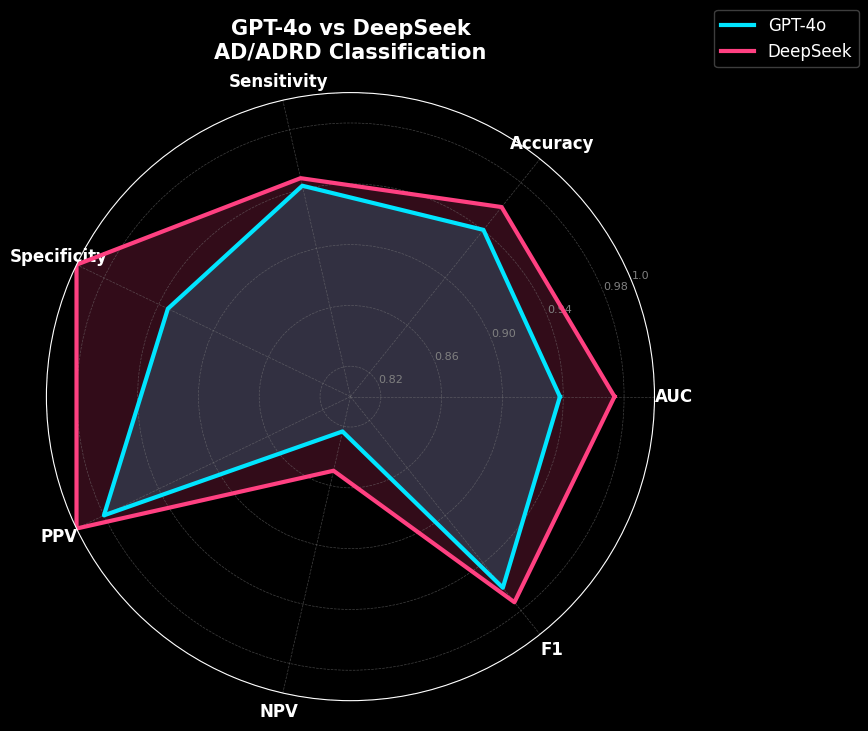

✅ Radar plot saved!


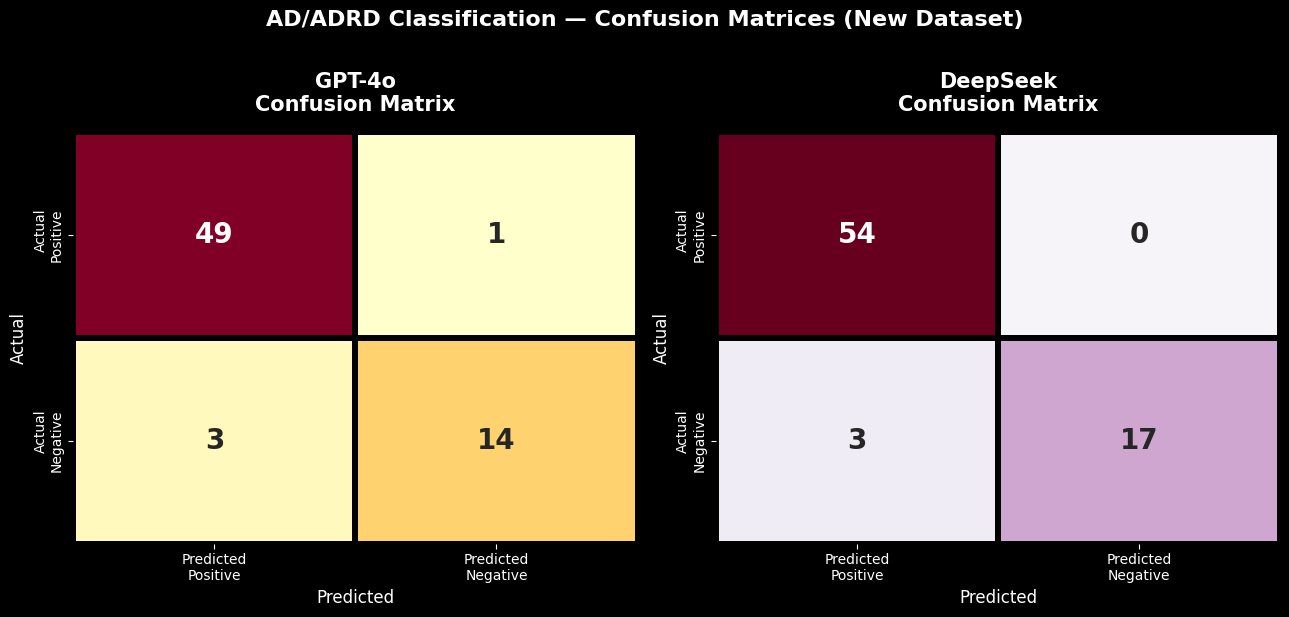

✅ Confusion matrices saved!


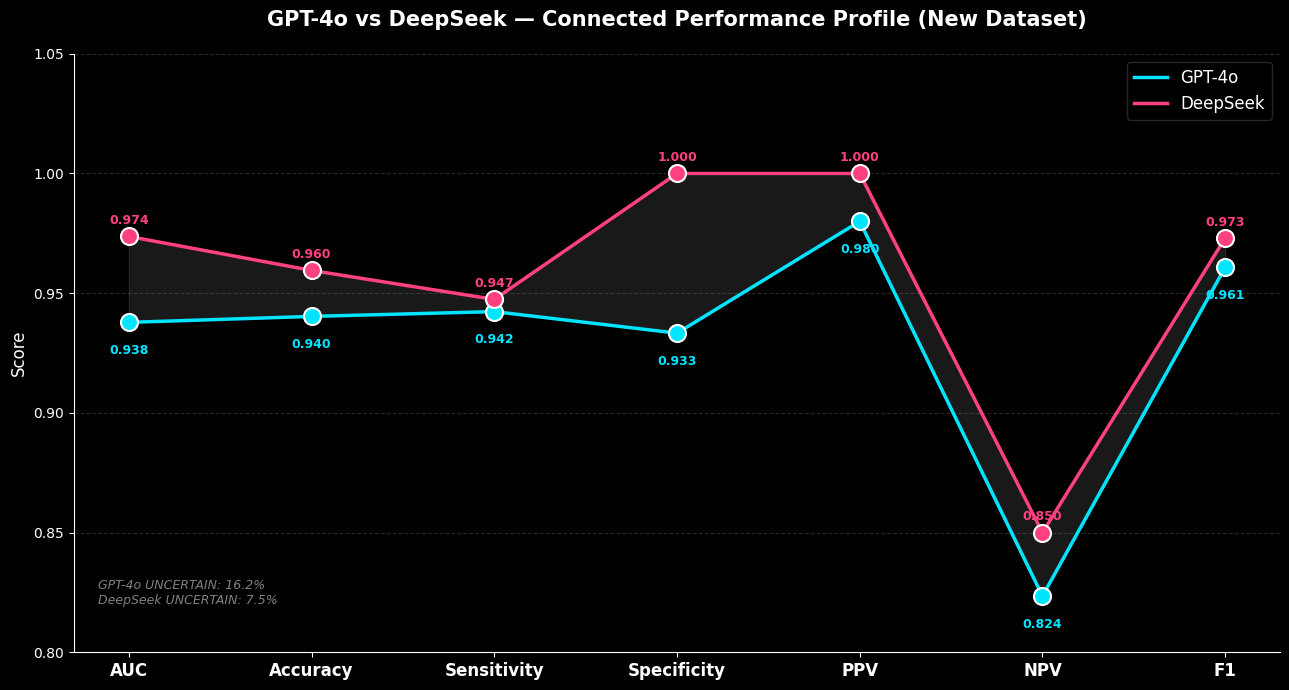

✅ Connected dot plot saved!


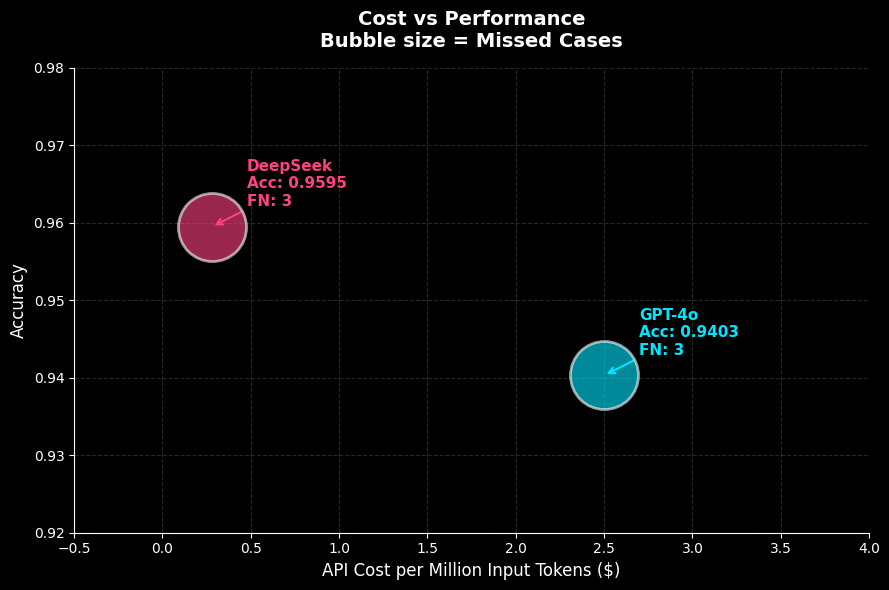

✅ Cost vs performance saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: v1_radar_new.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: v3_dot_new.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: v4_cost_new.png

🎉 All visuals updated and downloaded!


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from google.colab import files

GPT_COLOR = "#00E5FF"
DS_COLOR  = "#FF4081"

metrics = [
    "AUC", "Accuracy", "Sensitivity",
    "Specificity", "PPV", "NPV", "F1"
]
gpt_vals = [
    0.9378, 0.9403, 0.9423,
    0.9333, 0.9800, 0.8235, 0.9608
]
ds_vals = [
    0.9737, 0.9595, 0.9474,
    1.0000, 1.0000, 0.8500, 0.9730
]

# ── Visual 1: Radar Plot ──
plt.style.use("dark_background")
N = len(metrics)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
gpt_r = gpt_vals + gpt_vals[:1]
ds_r  = ds_vals  + ds_vals[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
ax.plot(angles, gpt_r, linewidth=3, label="GPT-4o", color=GPT_COLOR)
ax.fill(angles, gpt_r, alpha=0.2, color=GPT_COLOR)
ax.plot(angles, ds_r,  linewidth=3, label="DeepSeek", color=DS_COLOR)
ax.fill(angles, ds_r,  alpha=0.2, color=DS_COLOR)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=12, fontweight="bold", color="white")
ax.set_ylim(0.80, 1.0)
ax.set_yticks([0.82, 0.86, 0.90, 0.94, 0.98, 1.0])
ax.set_yticklabels(
    ["0.82","0.86","0.90","0.94","0.98","1.0"],
    size=8, color="grey"
)
ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_title(
    "GPT-4o vs DeepSeek\nAD/ADRD Classification",
    size=15, fontweight="bold", pad=25, color="white"
)
legend = ax.legend(
    loc="upper right", bbox_to_anchor=(1.35, 1.15),
    fontsize=12, framealpha=0.3
)
for t in legend.get_texts():
    t.set_color("white")
plt.tight_layout()
plt.savefig("v1_radar_new.png", dpi=300, bbox_inches="tight", facecolor="black")
plt.show()
plt.close()
print("✅ Radar plot saved!")

# ── Visual 2: Confusion Matrices ──
import seaborn as sns
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
gpt_cm = np.array([[49, 1], [3, 14]])
ds_cm  = np.array([[54, 0], [3, 17]])

for ax, cm, title, cmap in zip(
    axes,
    [gpt_cm, ds_cm],
    ["GPT-4o", "DeepSeek"],
    ["YlOrRd", "PuRd"]
):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=["Predicted\nPositive","Predicted\nNegative"],
        yticklabels=["Actual\nPositive","Actual\nNegative"],
        ax=ax, linewidths=3, linecolor="black",
        annot_kws={"size": 20, "weight": "bold"}, cbar=False
    )
    ax.set_title(
        f"{title}\nConfusion Matrix",
        fontsize=15, fontweight="bold", pad=15, color="white"
    )
    ax.set_ylabel("Actual", fontsize=12, color="white")
    ax.set_xlabel("Predicted", fontsize=12, color="white")
    ax.tick_params(colors="white")

plt.suptitle(
    "AD/ADRD Classification — Confusion Matrices",
    fontsize=16, fontweight="bold", y=1.02, color="white"
)
plt.tight_layout()
plt.savefig("v2_confusion_new.png", dpi=300, bbox_inches="tight", facecolor="black")
plt.show()
plt.close()
print("✅ Confusion matrices saved!")

# ── Visual 3: Connected Dot Plot ──
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(metrics))

ax.plot(x, gpt_vals, color=GPT_COLOR, linewidth=2.5, label="GPT-4o", zorder=3)
ax.plot(x, ds_vals,  color=DS_COLOR,  linewidth=2.5, label="DeepSeek", zorder=3)
ax.scatter(x, gpt_vals, color=GPT_COLOR, s=150, zorder=5, edgecolors="white", linewidth=1.5)
ax.scatter(x, ds_vals,  color=DS_COLOR,  s=150, zorder=5, edgecolors="white", linewidth=1.5)
ax.fill_between(x, gpt_vals, ds_vals, alpha=0.1, color="white")

for i, (g, d) in enumerate(zip(gpt_vals, ds_vals)):
    ax.text(x[i], g - 0.009, f"{g:.3f}", ha="center", va="top",
            fontsize=9, fontweight="bold", color=GPT_COLOR)
    ax.text(x[i], d + 0.004, f"{d:.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=DS_COLOR)

ax.annotate(
    "GPT-4o UNCERTAIN: 16.2%\nDeepSeek UNCERTAIN: 7.5%",
    xy=(0.02, 0.08), xycoords="axes fraction",
    fontsize=9, color="grey", style="italic"
)
ax.set_ylim(0.80, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight="bold", color="white")
ax.set_ylabel("Score", fontsize=12, color="white")
ax.set_title(
    "GPT-4o vs DeepSeek — Connected Performance Profile",
    fontsize=15, fontweight="bold", pad=20, color="white"
)
ax.legend(fontsize=12, framealpha=0.3, edgecolor="grey")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="grey")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("v3_dot_new.png", dpi=300, bbox_inches="tight", facecolor="black")
plt.show()
plt.close()
print("✅ Connected dot plot saved!")

# ── Visual 4: Cost vs Performance ──
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(9, 6))

models_data = {
    "GPT-4o":   {"cost": 2.50, "accuracy": 0.9403, "fn": 3, "color": GPT_COLOR},
    "DeepSeek": {"cost": 0.28, "accuracy": 0.9595, "fn": 3, "color": DS_COLOR}
}
for model, data in models_data.items():
    ax.scatter(
        data["cost"], data["accuracy"],
        s=data["fn"] * 800, color=data["color"],
        alpha=0.6, edgecolors="white", linewidth=2, zorder=5
    )
    ax.annotate(
        f"{model}\nAcc: {data['accuracy']:.4f}\nFN: {data['fn']}",
        xy=(data["cost"], data["accuracy"]),
        xytext=(25, 15), textcoords="offset points",
        fontsize=11, fontweight="bold", color=data["color"],
        arrowprops=dict(arrowstyle="->", color=data["color"], lw=1.5)
    )

ax.set_xlabel("API Cost per Million Input Tokens ($)", fontsize=12, color="white")
ax.set_ylabel("Accuracy", fontsize=12, color="white")
ax.set_title(
    "Cost vs Performance\nBubble size = Missed Cases",
    fontsize=14, fontweight="bold", pad=15, color="white"
)
ax.set_xlim(-0.5, 4)
ax.set_ylim(0.92, 0.98)
ax.grid(linestyle="--", alpha=0.3, color="grey")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("v4_cost_new.png", dpi=300, bbox_inches="tight", facecolor="black")
plt.show()
plt.close()
print("✅ Cost vs performance saved!")

# ── Download all ──
for f in ["v1_radar.png","v2_confusion.png",
          "v3_dot.png","v4_cost.png"]:
    files.download(f)
    print(f"✅ Downloaded: {f}")

print("\n🎉 All visuals updated and downloaded!")